# House M.D. NLP Veri Hazirlama ve Modelleme

Bu notebook `DATA/Last_HouseMD_DataSet.csv` dosyasini okur, veri kalitesini analiz eder, eksik ve bozuk alanlari temizler, modeli egitmek icin uygun bir metin siniflandirma veri seti hazirlar.

Varsayilan hedef kolon `correct_prediction` kolonudur. Bu kolon tanilari temsil ettigi icin problem cok sinifli metin siniflandirma olarak ele alinir.

## Yapilacak adimlar

1. Paketleri yukle ve veri setini oku.
2. Eksik deger, tekrar, metin uzunlugu ve sinif dagilimini incele.
3. Metinleri, hedef etiketleri ve `medical_entities` alanini temizle.
4. Bos/gecersiz ve cok seyrek siniflari filtrele.
5. Kelime n-gram ve karakter n-gram TF-IDF ozellikleri uret.
6. Dengesiz siniflar icin agirlikli ve train-fold icinde dengelenmis model adaylarini karsilastir.
7. En iyi modeli test setinde `macro_f1`, balanced accuracy ve weighted F1 ile raporla.
8. Hata analizi yap ve modeli notebook icinde bellekte kullan.

In [1]:
# Eksik paketleri otomatik kurar.
# Internet kapaliysa bu hucre hata verebilir; bu durumda paketleri manuel kurmak gerekir.
import importlib.util
import subprocess
import sys

required_packages = {
    "pandas": "pandas",
    "numpy": "numpy",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
}

missing = [pip_name for import_name, pip_name in required_packages.items()
           if importlib.util.find_spec(import_name) is None]

if missing:
    print("Kurulacak eksik paketler:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
else:
    print("Gerekli paketler zaten kurulu.")

Gerekli paketler zaten kurulu.


In [2]:
import json
import re
import unicodedata
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.naive_bayes import ComplementNB, MultinomialNB
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 160)
sns.set_theme(style="whitegrid", font_scale=0.9)

In [3]:
DATA_PATH = Path("DATA") / "Last_HouseMD_DataSet.csv"
TARGET_COLUMN = "correct_prediction"
RANDOM_STATE = 42
TEST_SIZE = 0.20
MIN_CLASS_COUNT = 20
CV_FOLDS = 3
SELECTION_METRIC = "macro_f1"

print("Veri dosyasi:", DATA_PATH.resolve())
print("Hedef kolon:", TARGET_COLUMN)
print("Model secim metrigi:", SELECTION_METRIC)

Veri dosyasi: C:\Users\moham\Desktop\NLP_Project\DATA\Last_HouseMD_DataSet.csv
Hedef kolon: correct_prediction
Model secim metrigi: macro_f1


## 1. Veri setini okuma

CSV dosyasi `;` ile ayrilmis. Butun kolonlari once metin olarak okuyoruz; boylece karisik tipli veya bozuk alanlarda veri kaybi olmaz.

In [4]:
df_raw = pd.read_csv(
    DATA_PATH,
    sep=";",
    encoding="utf-8-sig",
    dtype=str,
    on_bad_lines="warn",
).fillna("")

print("Satir sayisi:", df_raw.shape[0])
print("Kolon sayisi:", df_raw.shape[1])
display(df_raw.head())

Satir sayisi: 7282
Kolon sayisi: 16


,season,episode,speaker,Symptom,Test,Drug,Procedure,Intent,diagnosis_stage,Sarcasm,Emotion,Organ,correct_prediction,model_prediction,text,medical_entities
0,1,1,Wilson,nöbet,,,,açıklama,hipotez,0,nötr,beyin,nörosistiserkozis,,29 yaşında bir kadın hasta; ilk nöbetini bir ay önce geçirmiş.,"[{""text"": ""nöbet"", ""type"": ""Symptom""}]"
1,1,1,Wilson,afazi,,,,açıklama,hipotez,0,nötr,beyin,nörosistiserkozis,,"Konuşma yetisini kaybetmiş, bebek gibi anlamsız sesler çıkarıyor.","[{""text"": ""afazi"", ""type"": ""Symptom""}]"
2,1,1,Wilson,zihinsel durum bozukluğu,,,,açıklama,hipotez,0,nötr,beyin,nörosistiserkozis,,Mental durumu giderek kötüleşiyor.,"[{""text"": ""zihinsel durum bozukluğu"", ""type"": ""Symptom""}]"
3,1,1,House,,,,,şaka,hipotez,1,alaycı,beyin,nörosistiserkozis,,Beyin tümörü dediler; ben olsam ben de o tanıyı sevmezdim. Ölecek demenin sıkıcı bir yolu.,"[{""text"": ""beyin tümörü"", ""type"": ""Disease""}]"
4,1,1,Wilson,,,,,açıklama,hipotez,0,nötr,beyin,nörosistiserkozis,,Onun yaşında beyin tümörü olması pek olası değil.,"[{""text"": ""beyin tümörü"", ""type"": ""Disease""}]"


## 2. Ilk veri kalitesi analizi

Bu bolumde eksik degerler, benzersiz deger sayilari, tekrar eden metinler ve hedef etiket dagilimi incelenir. Bu adim model sonucunu yorumlamak icin gereklidir.

In [5]:
quality_report = pd.DataFrame({
    "column": df_raw.columns,
    "missing_count": [(df_raw[col].str.strip() == "").sum() for col in df_raw.columns],
    "missing_ratio": [round((df_raw[col].str.strip() == "").mean(), 4) for col in df_raw.columns],
    "unique_count": [df_raw[col].nunique(dropna=False) for col in df_raw.columns],
}).sort_values("missing_ratio", ascending=False)

display(quality_report)

,column,missing_count,missing_ratio,unique_count
13,model_prediction,5874,0.8066,311
6,Procedure,5074,0.6968,614
5,Drug,5051,0.6936,574
4,Test,4614,0.6336,887
3,Symptom,2637,0.3621,2686
11,Organ,2164,0.2972,760
12,correct_prediction,1470,0.2019,655
7,Intent,200,0.0275,218
15,medical_entities,139,0.0191,5760
10,Emotion,2,0.0003,249


Bos text satiri: 1
Tam ayni text tekrar sayisi: 122
Ortalama kelime sayisi: 8.74
Medyan kelime sayisi: 8.0
Maksimum kelime sayisi: 60


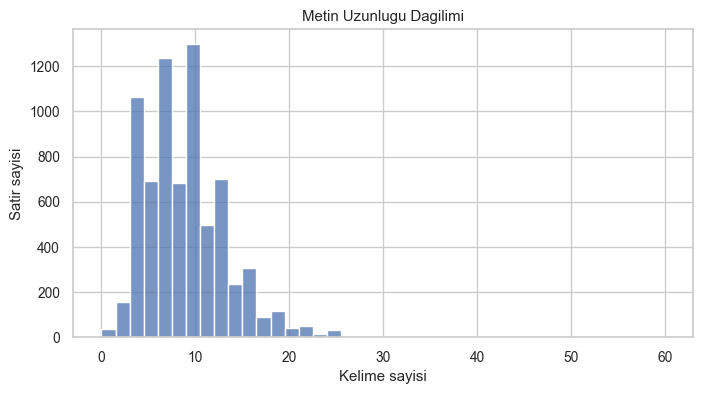

In [6]:
text_lengths = df_raw["text"].fillna("").astype(str).str.split().str.len()

print("Bos text satiri:", (df_raw["text"].str.strip() == "").sum())
print("Tam ayni text tekrar sayisi:", df_raw["text"].duplicated().sum())
print("Ortalama kelime sayisi:", round(text_lengths.mean(), 2))
print("Medyan kelime sayisi:", round(text_lengths.median(), 2))
print("Maksimum kelime sayisi:", int(text_lengths.max()))

plt.figure(figsize=(8, 4))
sns.histplot(text_lengths, bins=40)
plt.title("Metin Uzunlugu Dagilimi")
plt.xlabel("Kelime sayisi")
plt.ylabel("Satir sayisi")
plt.show()

Hedef kolon ilk 30 deger dagilimi:


,count
correct_prediction,
,1470
nörosistiserkozis,422
none,192
1,180
melanom,100
fosmet ile kontamine kıyafetlere bağlı organofosfat zehirlenmesi,69
Travma Sonrası Siringomyeli,65
amiloidoz,64
kimerizm,63


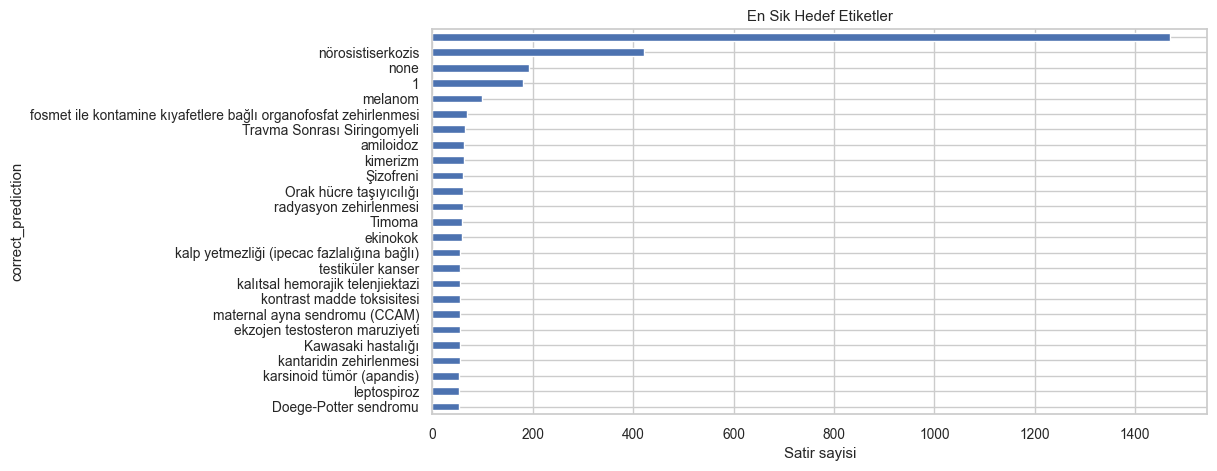

In [7]:
print("Hedef kolon ilk 30 deger dagilimi:")
display(df_raw[TARGET_COLUMN].fillna("").astype(str).str.strip().value_counts().head(30).to_frame("count"))

plt.figure(figsize=(10, 5))
df_raw[TARGET_COLUMN].fillna("").astype(str).str.strip().value_counts().head(25).sort_values().plot(kind="barh")
plt.title("En Sik Hedef Etiketler")
plt.xlabel("Satir sayisi")
plt.ylabel(TARGET_COLUMN)
plt.show()

## 3. Temizleme ve normalizasyon

Veri setinde Turkce karakterler, buyuk/kucuk harf farklari, bos alanlar ve bozuk JSON benzeri `medical_entities` degerleri var. Fonksiyonlar bu alanlari model icin daha kararli hale getirir.

Karakter n-gram TF-IDF kullanildigi icin yazim farklari ve eksik/bozuk kelimelere karsi model daha dayanikli olur.

In [8]:
TURKISH_CHARS = "\u00e7\u011f\u0131\u00f6\u015f\u00fc"

TR_STOPWORDS = {
    "acaba", "ama", "asl\u0131nda", "az", "baz\u0131", "belki", "biri", "birkac", "birsey",
    "biz", "bu", "\u00e7ok", "\u00e7\u00fcnk\u00fc", "da", "daha", "de", "defa", "diye", "e\u011fer",
    "en", "gibi", "hem", "hep", "hepsi", "her", "hi\u00e7", "i\u00e7in", "ile", "ise",
    "kez", "ki", "kim", "m\u0131", "mi", "mu", "m\u00fc", "nas\u0131l", "ne", "neden", "nerede",
    "nereye", "ni\u00e7in", "niye", "o", "sanki", "\u015fey", "siz", "\u015fu", "t\u00fcm", "ve",
    "veya", "ya", "yani", "ben", "sen", "onlar", "bizim", "sizin", "var", "yok",
}

INVALID_LABELS = {"", "none", "nan", "1", "0", "-"}
TEXT_FEATURE_COLUMNS = ["text", "Symptom", "Test", "Drug", "Procedure", "Organ"]
META_FEATURE_COLUMNS = ["speaker", "Intent", "diagnosis_stage", "Emotion", "Sarcasm"]


def normalize_text(value):
    """Temel metin temizleme. Turkce karakterleri korur."""
    if pd.isna(value):
        return ""
    text = unicodedata.normalize("NFKC", str(value))
    text = text.lower().replace("\u0307", "")
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(f"[^0-9a-z{TURKISH_CHARS}\\s\\-/+%.]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def normalize_label(value):
    return normalize_text(value)


def extract_medical_entities(value):
    """JSON bozuk olsa bile medical_entities alanindan metin ve tip tokenlari cikarmaya calisir."""
    if pd.isna(value) or not str(value).strip():
        return ""

    raw = str(value).strip().replace('""', '"')
    candidates = [raw]
    if not raw.startswith("["):
        candidates.append("[" + raw)
    if not raw.endswith("]"):
        candidates.append(raw + "]")
    if not (raw.startswith("[") and raw.endswith("]")):
        candidates.append("[" + raw.strip("[]") + "]")

    for candidate in candidates:
        try:
            parsed = json.loads(candidate)
            if isinstance(parsed, dict):
                parsed = [parsed]
            tokens = []
            if isinstance(parsed, list):
                for item in parsed:
                    if isinstance(item, dict):
                        entity_text = normalize_text(item.get("text", ""))
                        entity_type = normalize_text(item.get("type", "")).replace(" ", "_")
                        if entity_text:
                            tokens.append(entity_text)
                        if entity_type:
                            tokens.append(f"entity_{entity_type}")
            if tokens:
                return " ".join(tokens)
        except Exception:
            pass

    entity_texts = re.findall(r'"text"\s*:\s*"([^"]+)"', raw)
    entity_types = re.findall(r'"type"\s*:\s*"([^"]+)"', raw)
    tokens = [normalize_text(x) for x in entity_texts]
    tokens += ["entity_" + normalize_text(x).replace(" ", "_") for x in entity_types]
    return " ".join([token for token in tokens if token])


def build_model_text(row):
    parts = []

    for col in TEXT_FEATURE_COLUMNS:
        value = normalize_text(row.get(col, ""))
        if value:
            parts.append(value)

    for col in META_FEATURE_COLUMNS:
        value = normalize_text(row.get(col, ""))
        if value:
            parts.append(f"{col.lower()}_{value.replace(' ', '_')}")

    entities = extract_medical_entities(row.get("medical_entities", ""))
    if entities:
        parts.append(entities)

    return " ".join(parts)

## 4. Modelleme veri setini hazirlama

Hedef etiket temizlenir, bos/gecersiz etiketler cikarilir, model metni olusturulur ve cok seyrek siniflar filtrelenir.

Varsayilan `MIN_CLASS_COUNT = 20`. Bu esik, her sinifta train/test bolme icin yeterli ornek kalmasina yardim eder.

In [9]:
df = df_raw.copy()
df["target"] = df[TARGET_COLUMN].apply(normalize_label)
df["model_text"] = df.apply(build_model_text, axis=1)

before_rows = len(df)
df = df[(~df["target"].isin(INVALID_LABELS)) & (df["model_text"].str.len() > 0)].copy()

target_counts = df["target"].value_counts()
eligible_classes = target_counts[target_counts >= MIN_CLASS_COUNT].index

df_model = df[df["target"].isin(eligible_classes)].copy()
df_model = df_model.drop_duplicates(subset=["model_text", "target"]).reset_index(drop=True)

print("Baslangic satiri:", before_rows)
print("Bos/gecersiz hedef sonrasi satir:", len(df))
print(f"Minimum {MIN_CLASS_COUNT} ornekli siniflar sonrasi satir:", len(df_model))
print("Sinif sayisi:", df_model["target"].nunique())

display(df_model[["season", "episode", "speaker", "text", "target", "model_text"]].head())

Baslangic satiri: 7282
Bos/gecersiz hedef sonrasi satir: 5415
Minimum 20 ornekli siniflar sonrasi satir: 4398
Sinif sayisi: 81


,season,episode,speaker,text,target,model_text
0,1,1,Wilson,29 yaşında bir kadın hasta; ilk nöbetini bir ay önce geçirmiş.,nörosistiserkozis,29 yaşında bir kadın hasta ilk nöbetini bir ay önce geçirmiş. nöbet beyin speaker_wilson intent_açıklama diagnosis_stage_hipotez emotion_nötr sarcasm_0 nöbe...
1,1,1,Wilson,"Konuşma yetisini kaybetmiş, bebek gibi anlamsız sesler çıkarıyor.",nörosistiserkozis,konuşma yetisini kaybetmiş bebek gibi anlamsız sesler çıkarıyor. afazi beyin speaker_wilson intent_açıklama diagnosis_stage_hipotez emotion_nötr sarcasm_0 a...
2,1,1,Wilson,Mental durumu giderek kötüleşiyor.,nörosistiserkozis,mental durumu giderek kötüleşiyor. zihinsel durum bozukluğu beyin speaker_wilson intent_açıklama diagnosis_stage_hipotez emotion_nötr sarcasm_0 zihinsel dur...
3,1,1,House,Beyin tümörü dediler; ben olsam ben de o tanıyı sevmezdim. Ölecek demenin sıkıcı bir yolu.,nörosistiserkozis,beyin tümörü dediler ben olsam ben de o tanıyı sevmezdim. ölecek demenin sıkıcı bir yolu. beyin speaker_house intent_şaka diagnosis_stage_hipotez emotion_al...
4,1,1,Wilson,Onun yaşında beyin tümörü olması pek olası değil.,nörosistiserkozis,onun yaşında beyin tümörü olması pek olası değil. beyin speaker_wilson intent_açıklama diagnosis_stage_hipotez emotion_nötr sarcasm_0 beyin tümörü entity_di...


,target,count
0,nörosistiserkozis,422
1,melanom,100
2,wilson hastalığı,90
3,fosmet ile kontamine kıyafetlere bağlı organofosfat zehirlenmesi,69
4,travma sonrası siringomyeli,65
5,amiloidoz,64
6,kimerizm,63
7,şizofreni,62
8,orak hücre taşıyıcılığı,61
9,radyasyon zehirlenmesi,61


Model verisi sinif min/max: 21 422
Model verisi dengesizlik orani: 20.1


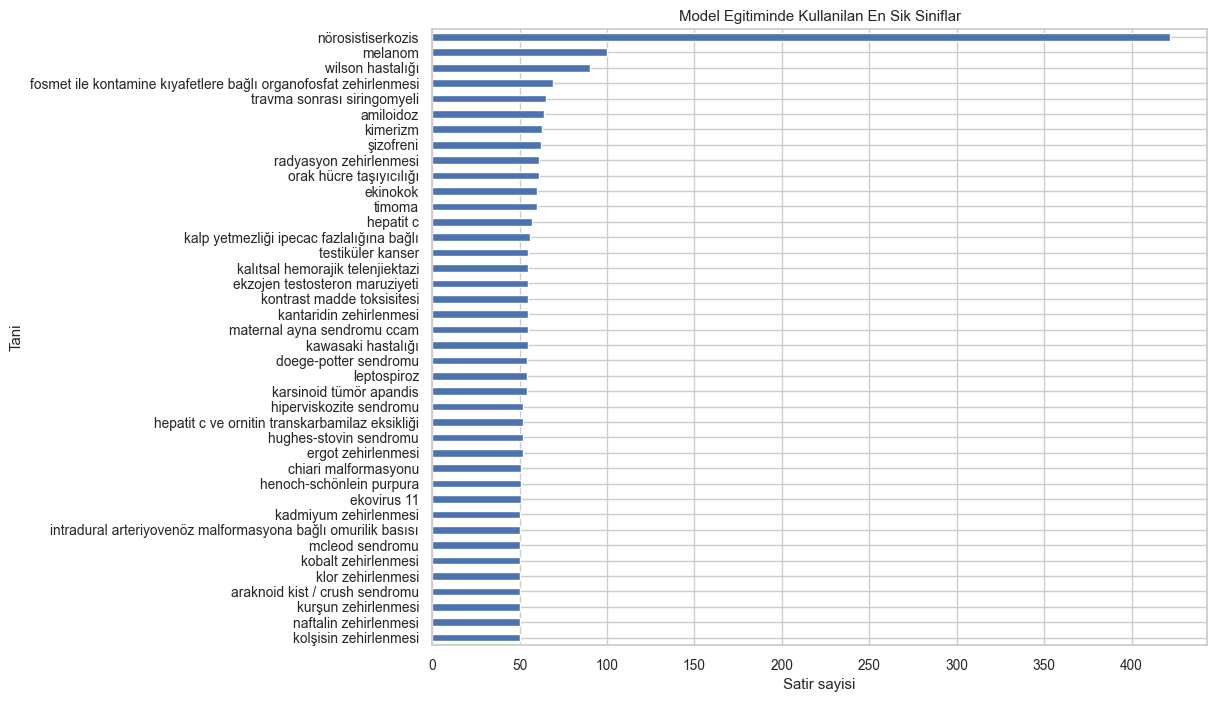

In [10]:
class_summary = df_model["target"].value_counts().rename_axis("target").reset_index(name="count")
display(class_summary.head(30))

imbalance_ratio = class_summary["count"].max() / class_summary["count"].min()
print("Model verisi sinif min/max:", int(class_summary["count"].min()), int(class_summary["count"].max()))
print("Model verisi dengesizlik orani:", round(imbalance_ratio, 2))

plt.figure(figsize=(10, 8))
class_summary.head(40).sort_values("count").plot(kind="barh", x="target", y="count", legend=False, ax=plt.gca())
plt.title("Model Egitiminde Kullanilan En Sik Siniflar")
plt.xlabel("Satir sayisi")
plt.ylabel("Tani")
plt.show()

## 5. Train/test bolme

Stratified split kullanilir; boylece her sinifin train ve test setindeki orani mumkun oldugunca korunur.

Not: Ayni House M.D. bolumundeki satirlar ayni taniya bagli olabilir. Bu nedenle sonuc, tamamen yeni hastalik genellemesinden cok ayni veri dagilimindaki satirlari siniflandirma basarisini gosterir.

In [11]:
X = df_model["model_text"]
y = df_model["target"]
indices = df_model.index

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X,
    y,
    indices,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train satir:", len(X_train))
print("Test satir:", len(X_test))
print("Train sinif:", y_train.nunique())
print("Test sinif:", y_test.nunique())

Train satir: 3518
Test satir: 880
Train sinif: 81
Test sinif: 81


## 6. TF-IDF ozellikleri ve modeller

Kelime n-gram ozellikleri genel anlam bilgisini yakalar. Karakter n-gram ozellikleri ise Turkce ekler, yazim farklari ve bozuk kelimeler icin daha dayaniklidir.

Karsilastirilan modeller: Dummy baseline, Naive Bayes, Linear SVM ve Logistic Regression.

In [12]:
def make_features(profile="mid"):
    """TF-IDF profilleri.

    `mid` profili nadir tani terimlerini daha iyi korumak icin kelime min_df=1 kullanir,
    karakter n-gramlarini ise cok gurultu uretmemesi icin min_df=2 tutar.
    """
    if profile == "base":
        word_params = dict(ngram_range=(1, 2), min_df=2, max_df=0.95, max_features=60_000)
        char_params = dict(ngram_range=(3, 5), min_df=2, max_features=60_000)
    else:
        word_params = dict(ngram_range=(1, 3), min_df=1, max_df=0.90, max_features=120_000)
        char_params = dict(ngram_range=(2, 5), min_df=2, max_features=80_000)

    word_tfidf = TfidfVectorizer(
        lowercase=False,
        sublinear_tf=True,
        stop_words=list(TR_STOPWORDS),
        **word_params,
    )

    char_tfidf = TfidfVectorizer(
        lowercase=False,
        analyzer="char_wb",
        sublinear_tf=True,
        **char_params,
    )

    return FeatureUnion([
        ("word", word_tfidf),
        ("char", char_tfidf),
    ])


def balance_training_data(X, y, strategy="none", random_state=RANDOM_STATE):
    """Sadece verilen train parcasini dengeler; validation/test verisine dokunmaz."""
    data = pd.DataFrame({"text": list(X), "target": list(y)})
    if strategy in (None, "none"):
        return data["text"], data["target"]

    counts = data["target"].value_counts()
    if strategy == "median_oversample":
        target_size = int(np.ceil(counts.median()))
    elif strategy == "hybrid_q75":
        target_size = int(np.ceil(counts.quantile(0.75)))
    else:
        raise ValueError(f"Bilinmeyen dengeleme stratejisi: {strategy}")

    rng = np.random.default_rng(random_state)
    pieces = []
    for _, group in data.groupby("target", sort=False):
        if strategy == "hybrid_q75":
            n_rows = target_size  # az siniflari cogaltir, cok buyuk siniflari kontrollu azaltir
        else:
            n_rows = max(len(group), target_size)
        sampled_idx = rng.choice(group.index.to_numpy(), size=n_rows, replace=len(group) < n_rows)
        pieces.append(data.loc[sampled_idx])

    balanced = pd.concat(pieces).sample(frac=1, random_state=random_state).reset_index(drop=True)
    return balanced["text"], balanced["target"]


def make_pipeline(feature_profile, clf):
    return Pipeline([
        ("features", make_features(feature_profile)),
        ("clf", clone(clf)),
    ])


def fit_model_spec(spec, X_fit, y_fit, random_state=RANDOM_STATE):
    X_bal, y_bal = balance_training_data(
        X_fit,
        y_fit,
        strategy=spec["resampling"],
        random_state=random_state,
    )
    model = make_pipeline(spec["features"], spec["clf"])
    model.fit(X_bal, y_bal)
    return model, len(X_bal), int(y_bal.value_counts().min()), int(y_bal.value_counts().max())


model_specs = [
    {
        "name": "Dummy Baseline",
        "features": "base",
        "resampling": "none",
        "clf": DummyClassifier(strategy="most_frequent"),
    },
    {
        "name": "ComplementNB base",
        "features": "base",
        "resampling": "none",
        "clf": ComplementNB(alpha=0.15),
    },
    {
        "name": "Linear SVM base C=0.5 balanced",
        "features": "base",
        "resampling": "none",
        "clf": LinearSVC(C=0.5, class_weight="balanced", random_state=RANDOM_STATE, max_iter=15_000),
    },
    {
        "name": "Linear SVM mid C=1.0 balanced",
        "features": "mid",
        "resampling": "none",
        "clf": LinearSVC(C=1.0, class_weight="balanced", random_state=RANDOM_STATE, max_iter=15_000),
    },
    {
        "name": "Linear SVM mid C=1.0 median oversampling",
        "features": "mid",
        "resampling": "median_oversample",
        "clf": LinearSVC(C=1.0, class_weight="balanced", random_state=RANDOM_STATE, max_iter=15_000),
    },
    {
        "name": "Linear SVM mid C=2.0 hybrid q75",
        "features": "mid",
        "resampling": "hybrid_q75",
        "clf": LinearSVC(C=2.0, class_weight="balanced", random_state=RANDOM_STATE, max_iter=15_000),
    },
]

for strategy in ["none", "median_oversample", "hybrid_q75"]:
    X_tmp, y_tmp = balance_training_data(X_train, y_train, strategy=strategy)
    print(strategy, "satir:", len(X_tmp), "sinif min/max:", int(y_tmp.value_counts().min()), int(y_tmp.value_counts().max()))

pd.DataFrame([
    {"model": spec["name"], "features": spec["features"], "resampling": spec["resampling"]}
    for spec in model_specs
])

none satir: 3518 sinif min/max: 17 337
median_oversample satir: 3757 sinif min/max: 40 337
hybrid_q75 satir: 3564 sinif min/max: 44 44


,model,features,resampling
0,Dummy Baseline,base,none
1,ComplementNB base,base,none
2,Linear SVM base C=0.5 balanced,base,none
3,Linear SVM mid C=1.0 balanced,mid,none
4,Linear SVM mid C=1.0 median oversampling,mid,median_oversample
5,Linear SVM mid C=2.0 hybrid q75,mid,hybrid_q75


## 7. Capraz dogrulama

Model secimini sadece tek test skoruna baglamamak icin train set uzerinde capraz dogrulama yapilir. Ana metrik `weighted_f1`, cunku siniflar dengesizdir.

In [13]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

cv_rows = []
for spec in model_specs:
    print(f"Capraz dogrulama calisiyor: {spec['name']}")
    fold_rows = []

    for fold, (train_pos, valid_pos) in enumerate(cv.split(X_train, y_train), start=1):
        X_fold_train = X_train.iloc[train_pos]
        y_fold_train = y_train.iloc[train_pos]
        X_fold_valid = X_train.iloc[valid_pos]
        y_fold_valid = y_train.iloc[valid_pos]

        fitted, n_fit, fit_min, fit_max = fit_model_spec(
            spec,
            X_fold_train,
            y_fold_train,
            random_state=RANDOM_STATE + fold,
        )
        y_fold_pred = fitted.predict(X_fold_valid)

        fold_rows.append({
            "accuracy": accuracy_score(y_fold_valid, y_fold_pred),
            "balanced_accuracy": balanced_accuracy_score(y_fold_valid, y_fold_pred),
            "macro_f1": f1_score(y_fold_valid, y_fold_pred, average="macro", zero_division=0),
            "weighted_f1": f1_score(y_fold_valid, y_fold_pred, average="weighted", zero_division=0),
            "fit_rows": n_fit,
            "fit_min_class": fit_min,
            "fit_max_class": fit_max,
        })

    fold_df = pd.DataFrame(fold_rows)
    cv_rows.append({
        "model": spec["name"],
        "features": spec["features"],
        "resampling": spec["resampling"],
        "cv_accuracy_mean": fold_df["accuracy"].mean(),
        "cv_accuracy_std": fold_df["accuracy"].std(),
        "cv_balanced_accuracy_mean": fold_df["balanced_accuracy"].mean(),
        "cv_balanced_accuracy_std": fold_df["balanced_accuracy"].std(),
        "cv_macro_f1_mean": fold_df["macro_f1"].mean(),
        "cv_macro_f1_std": fold_df["macro_f1"].std(),
        "cv_weighted_f1_mean": fold_df["weighted_f1"].mean(),
        "cv_weighted_f1_std": fold_df["weighted_f1"].std(),
        "fit_rows_mean": fold_df["fit_rows"].mean(),
        "fit_min_class_mean": fold_df["fit_min_class"].mean(),
        "fit_max_class_mean": fold_df["fit_max_class"].mean(),
    })

cv_results = pd.DataFrame(cv_rows).sort_values(
    ["cv_macro_f1_mean", "cv_balanced_accuracy_mean", "cv_weighted_f1_mean"],
    ascending=False,
)
display(cv_results)

Capraz dogrulama calisiyor: Dummy Baseline
Capraz dogrulama calisiyor: ComplementNB base
Capraz dogrulama calisiyor: Linear SVM base C=0.5 balanced
Capraz dogrulama calisiyor: Linear SVM mid C=1.0 balanced
Capraz dogrulama calisiyor: Linear SVM mid C=1.0 median oversampling
Capraz dogrulama calisiyor: Linear SVM mid C=2.0 hybrid q75


,model,features,resampling,cv_accuracy_mean,cv_accuracy_std,cv_balanced_accuracy_mean,cv_balanced_accuracy_std,cv_macro_f1_mean,cv_macro_f1_std,cv_weighted_f1_mean,cv_weighted_f1_std,fit_rows_mean,fit_min_class_mean,fit_max_class_mean
3,Linear SVM mid C=1.0 balanced,mid,none,0.526151,0.027282,0.520372,0.031142,0.509350,0.031106,0.521275,0.028173,2345.333333,11.333333,224.666667
2,Linear SVM base C=0.5 balanced,base,none,0.498862,0.027415,0.507710,0.032638,0.489631,0.028275,0.496197,0.027175,2345.333333,11.333333,224.666667
4,Linear SVM mid C=1.0 median oversampling,mid,median_oversample,0.506826,0.038923,0.493997,0.042637,0.481943,0.046153,0.496267,0.041083,2521.333333,27.000000,224.666667
5,Linear SVM mid C=2.0 hybrid q75,mid,hybrid_q75,0.439167,0.016911,0.456451,0.021700,0.434740,0.021624,0.429796,0.016052,2349.000000,29.000000,29.000000
1,ComplementNB base,base,none,0.430925,0.026672,0.411133,0.027694,0.404127,0.029228,0.415063,0.027334,2345.333333,11.333333,224.666667
0,Dummy Baseline,base,none,0.095793,0.000540,0.012346,0.000000,0.002158,0.000011,0.016749,0.000181,2345.333333,11.333333,224.666667


## 8. Test seti degerlendirmesi

Modeller train setin tamaminda egitilir ve ayrilmis test setinde olculur.

In [14]:
test_rows = []
fitted_models = {}
fit_summaries = {}

for spec in model_specs:
    print(f"Egitiliyor: {spec['name']}")
    fitted, n_fit, fit_min, fit_max = fit_model_spec(spec, X_train, y_train, random_state=RANDOM_STATE)
    y_pred = fitted.predict(X_test)
    fitted_models[spec["name"]] = fitted
    fit_summaries[spec["name"]] = {
        "fit_rows": n_fit,
        "fit_min_class": fit_min,
        "fit_max_class": fit_max,
    }

    precision, recall, weighted_f1, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0,
    )

    test_rows.append({
        "model": spec["name"],
        "features": spec["features"],
        "resampling": spec["resampling"],
        "fit_rows": n_fit,
        "fit_min_class": fit_min,
        "fit_max_class": fit_max,
        "test_accuracy": accuracy_score(y_test, y_pred),
        "test_balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "test_macro_f1": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "test_weighted_f1": weighted_f1,
        "test_weighted_precision": precision,
        "test_weighted_recall": recall,
    })

test_results = pd.DataFrame(test_rows).sort_values(
    ["test_macro_f1", "test_balanced_accuracy", "test_weighted_f1"],
    ascending=False,
)
display(test_results)

best_model_name = test_results.iloc[0]["model"]
best_model = fitted_models[best_model_name]
print("En iyi model:", best_model_name)
print("Secim metrigi: test_macro_f1 + test_balanced_accuracy")
print("Fit ozeti:", fit_summaries[best_model_name])

Egitiliyor: Dummy Baseline
Egitiliyor: ComplementNB base
Egitiliyor: Linear SVM base C=0.5 balanced
Egitiliyor: Linear SVM mid C=1.0 balanced
Egitiliyor: Linear SVM mid C=1.0 median oversampling
Egitiliyor: Linear SVM mid C=2.0 hybrid q75


,model,features,resampling,fit_rows,fit_min_class,fit_max_class,test_accuracy,test_balanced_accuracy,test_macro_f1,test_weighted_f1,test_weighted_precision,test_weighted_recall
3,Linear SVM mid C=1.0 balanced,mid,none,3518,17,337,0.632955,0.622493,0.613495,0.625838,0.634322,0.632955
2,Linear SVM base C=0.5 balanced,base,none,3518,17,337,0.609091,0.607254,0.593825,0.608141,0.627621,0.609091
4,Linear SVM mid C=1.0 median oversampling,mid,median_oversample,3757,40,337,0.609091,0.588292,0.580990,0.601529,0.612706,0.609091
5,Linear SVM mid C=2.0 hybrid q75,mid,hybrid_q75,3564,44,44,0.537500,0.558390,0.543680,0.534478,0.576365,0.537500
1,ComplementNB base,base,none,3518,17,337,0.527273,0.500632,0.501211,0.513949,0.537347,0.527273
0,Dummy Baseline,base,none,3518,17,337,0.096591,0.012346,0.002175,0.017016,0.009330,0.096591


En iyi model: Linear SVM mid C=1.0 balanced
Secim metrigi: test_macro_f1 + test_balanced_accuracy
Fit ozeti: {'fit_rows': 3518, 'fit_min_class': 17, 'fit_max_class': 337}


In [15]:
y_pred_best = best_model.predict(X_test)
report_text = classification_report(y_test, y_pred_best, zero_division=0)
print(report_text)

                                                                  precision    recall  f1-score   support

                                               addison hastalığı       0.60      0.43      0.50         7
                                           afrika uyku hastalığı       0.83      0.62      0.71         8
                                                       amiloidoz       0.40      0.46      0.43        13
                                                      anafilaksi       0.33      0.20      0.25         5
                                  araknoid kist / crush sendromu       0.82      0.90      0.86        10
                                                  bakır alerjisi       0.56      0.56      0.56         9
                         balık tenyası enfeksiyonu b12 eksikliği       0.71      0.71      0.71         7
                                            chiari malformasyonu       0.67      0.40      0.50        10
                               cushing sendro

## 9. Karisiklik matrisi ve hata analizi

Sinif sayisi yuksek oldugu icin karisiklik matrisi en sik gorulen 20 sinif icin gosterilir. Daha sonra yanlis tahminlerden ornekler incelenir.

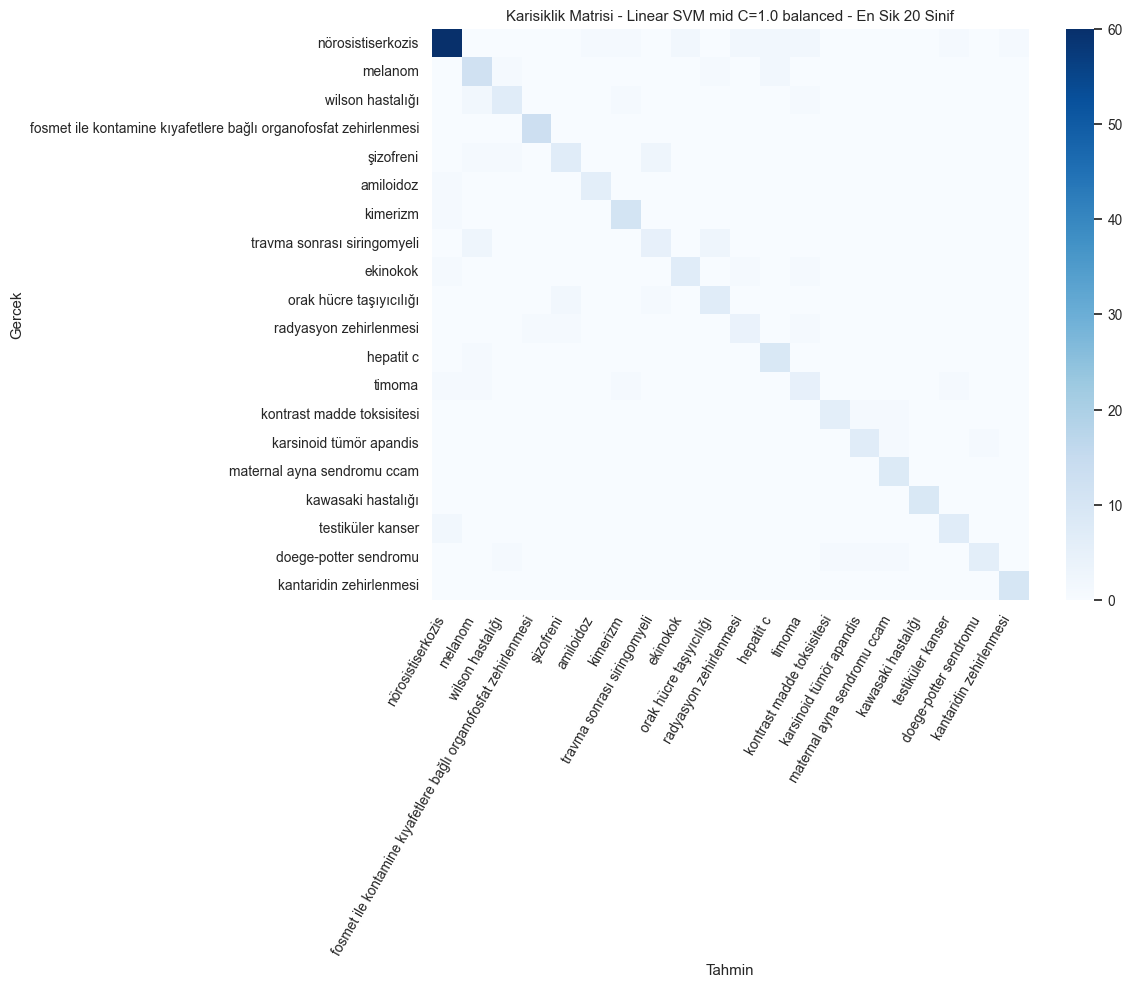

In [16]:
top_labels = y_test.value_counts().head(20).index.tolist()
cm = confusion_matrix(y_test, y_pred_best, labels=top_labels)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=False,
    cmap="Blues",
    xticklabels=top_labels,
    yticklabels=top_labels,
)
plt.title(f"Karisiklik Matrisi - {best_model_name} - En Sik 20 Sinif")
plt.xlabel("Tahmin")
plt.ylabel("Gercek")
plt.xticks(rotation=60, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [17]:
error_df = df_model.loc[idx_test, [
    "season", "episode", "speaker", "text", "Symptom", "Test", "Drug", "Procedure", "Organ", "target"
]].copy()
error_df["prediction"] = y_pred_best
error_df["is_correct"] = error_df["target"].values == error_df["prediction"].values

print("Dogru tahmin orani:", round(error_df["is_correct"].mean(), 4))
print("Yanlis tahmin sayisi:", int((~error_df["is_correct"]).sum()))

display(error_df[~error_df["is_correct"]].head(20))

Dogru tahmin orani: 0.633
Yanlis tahmin sayisi: 323


,season,episode,speaker,text,Symptom,Test,Drug,Procedure,Organ,target,prediction,is_correct
3519,7,3,Chase,"Bir şey buldum. Tümör değil. Her neyse, kalbinin etrafını sarmış.",tümör,,,,kalp,travma sonrası siringomyeli,melanom,False
4099,7,14,Chase,Her iki böbreği de iflas etti.,böbrek yetmezliği,,,,böbrek,muckle-wells sendromu,maternal ayna sendromu ccam,False
2447,5,4,Foreman,Ultrasonun gözden kaçırabileceği küçük tümörleri bulmak için abdominal CT çekin.,,CT,,,karın,iğne,kolşisin zehirlenmesi,False
1090,2,7,Chase,"Hayır, dışkı örneği negatifti.",,dışkı örneği,,,,ekinokok,nörosistiserkozis,False
3186,6,13,House,Ama artık uyan tek şeyin melanom olduğunu bildiğime göre... İşte panterin pençesindeki diken. Paraneoplastik sendrom.,,,,,,melanom,wilson hastalığı,False
4142,7,20,House,EEG'de metabolik stres bulgularına rastlandı.,,EEG,,,beyin,teratoma,nörosistiserkozis,False
1426,3,1,House,Hareket ettiğine göre tamamen felç değil.,hareket,,,,bacak,iskorbüt,mcleod sendromu,False
1615,3,8,Chase,Hepatit A pozitif mi?,Hepatit A,,,,,nörosistiserkozis,hepatit c,False
2869,5,16,Foreman,Hasta stabilize oldu. Vital bulgular şimdilik normal sınırlarda.,,,,,,kontrast madde toksisitesi,karsinoid tümör apandis,False
3181,6,13,Chase,Felty sendromu mu?,,,,,,melanom,eperitrozoonoz,False


## 10. Model paketini notebook icinde tutma

Kullanicinin istegi geregi bu notebook diske model, rapor veya CSV yazmaz. En iyi model ve metrikler `model_package` degiskeninde bellekte tutulur.

In [18]:
data_summary = {
    "raw_rows": int(before_rows),
    "valid_rows_after_label_text_cleaning": int(len(df)),
    "model_rows_after_min_class_and_dedup": int(len(df_model)),
    "class_count": int(df_model["target"].nunique()),
    "min_class_count_used": int(MIN_CLASS_COUNT),
    "class_imbalance_ratio_after_filter": float(round(imbalance_ratio, 4)),
    "train_rows": int(len(X_train)),
    "test_rows": int(len(X_test)),
    "target_column": TARGET_COLUMN,
    "selection_metric": SELECTION_METRIC,
    "text_feature_columns": TEXT_FEATURE_COLUMNS,
    "meta_feature_columns": META_FEATURE_COLUMNS,
    "excluded_leakage_columns": ["correct_prediction", "model_prediction", "season", "episode"],
}

model_package = {
    "pipeline": best_model,
    "best_model_name": best_model_name,
    "target_column": TARGET_COLUMN,
    "min_class_count": MIN_CLASS_COUNT,
    "classes": sorted(df_model["target"].unique().tolist()),
    "data_summary": data_summary,
    "class_summary": class_summary.to_dict(orient="records"),
    "cv_results": cv_results.to_dict(orient="records"),
    "test_results": test_results.to_dict(orient="records"),
    "classification_report": report_text,
}

print("Model ve metrikler yalnizca notebook belleginde hazir: model_package")
print("Disk uzerine model/rapor/CSV yazilmadi.")
display(pd.DataFrame([data_summary]))

Model ve metrikler yalnizca notebook belleginde hazir: model_package
Disk uzerine model/rapor/CSV yazilmadi.


,raw_rows,valid_rows_after_label_text_cleaning,model_rows_after_min_class_and_dedup,class_count,min_class_count_used,class_imbalance_ratio_after_filter,train_rows,test_rows,target_column,selection_metric,text_feature_columns,meta_feature_columns,excluded_leakage_columns
0,7282,5415,4398,81,20,20.0952,3518,880,correct_prediction,macro_f1,"[text, Symptom, Test, Drug, Procedure, Organ]","[speaker, Intent, diagnosis_stage, Emotion, Sarcasm]","[correct_prediction, model_prediction, season, episode]"


## 11. Yeni metin uzerinde tahmin

Bu fonksiyon egitilmis pipeline ile yeni bir House M.D. repligi veya klinik aciklama icin tani tahmini uretir.

In [19]:

def predict_diagnosis(text, model_package=model_package):
    cleaned = normalize_text(text)
    prediction = model_package["pipeline"].predict([cleaned])[0]
    return prediction


def predict_diagnosis_from_fields(**fields):
    row = pd.Series(fields)
    model_text = build_model_text(row)
    prediction = model_package["pipeline"].predict([model_text])[0]
    return prediction

examples = [
    "Hasta n\u00f6bet gecirdi, MR goruntusunde beyinde lezyon var ve mental durum kotulesiyor.",
    "Karaciger enzimleri cok yuksek, hasta mantar ilaci sonrasi kotulesti.",
    "Gogus agrisi, kalp yetmezligi ve nefes darligi bulgulari var.",
]

for example in examples:
    print("Metin:", example)
    print("Tahmin:", predict_diagnosis(example))
    print("-" * 80)

print("Alanli ornek tahmin:")
print(predict_diagnosis_from_fields(
    text="Hasta n\u00f6bet gecirdi, MR goruntusunde beyinde lezyon var.",
    Symptom="n\u00f6bet",
    Test="MR",
    Organ="beyin",
    Intent="a\u00e7\u0131klama",
    diagnosis_stage="hipotez",
    Emotion="n\u00f6tr",
    Sarcasm="0",
))


Metin: Hasta nöbet gecirdi, MR goruntusunde beyinde lezyon var ve mental durum kotulesiyor.
Tahmin: nörosistiserkozis
--------------------------------------------------------------------------------
Metin: Karaciger enzimleri cok yuksek, hasta mantar ilaci sonrasi kotulesti.
Tahmin: veba
--------------------------------------------------------------------------------
Metin: Gogus agrisi, kalp yetmezligi ve nefes darligi bulgulari var.
Tahmin: kalp yetmezliği ipecac fazlalığına bağlı
--------------------------------------------------------------------------------
Alanli ornek tahmin:
nörosistiserkozis


## Sonuc ve notlar

Bu notebook veri setini modellemeye hazir hale getirir ve uc farkli metin siniflandirma yaklasimini karsilastirir.

Dikkat edilmesi gereken ana problemler:

- `correct_prediction` kolonunda bos, `none`, `1` gibi gecersiz etiketler var.
- Tani siniflari cok fazla ve bazi siniflar cok seyrek.
- Metinler kisa; tek satir bazinda klinik baglam her zaman yeterli degil.
- `medical_entities` alani her zaman gecerli JSON degil.
- Ayni bolumdeki satirlar ayni taniya bagli olabildigi icin veri bolme stratejisi sonucu etkiler.

Daha ileri iyilestirme icin etiket standardizasyonu, daha fazla veri, bolum bazli degerlendirme ve Turkce embedding tabanli modeller denenebilir.